In [1]:
#LOADING MAIN LIBRARIES
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from tqdm import tqdm

import os

In [2]:
#SETTING UP MAIN DIRECTORIES
mainDirectory = "/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/"

In [3]:
#DIRECTORY FUNCTIONS
def ListFiles(directory, n=10):
    files = os.listdir(directory)
    print("Listing first", n, "files:\n", files[:n], "\n")
    return files

In [4]:
#LOADING CLASSES
# --- Add your Functions folder to sys.path ---
import sys
path = mainDirectory + '/Functions_2.0/Classes'
sys.path.append(path)

# --- Import all your function modules ---
import importlib
modules = [
    "Classes_MapPlotting"
]

for mod in modules:
    globals()[mod] = importlib.import_module(mod)        # import module itself
    globals().update(vars(globals()[mod]))              # import all functions into global namespace

In [5]:
################################################################################

In [6]:
#DATA DESCRIPTIONS

### Data Type
# PRECIP Radiosonde Dataset

### DOI (Permanent Link)
# https://doi.org/10.26023/5SS8-D6HT-5K0N

### Summary
# Data from the Colorado State University radiosonde systems that were deployed at Hsinchu, Taiwan and Yonaguni, Japan for the PRECIP campaign. Measurements include vertical profiles of temperature, moisture and winds.

### Temporal Coverage
# Begin datetime 2022-05-24 00:00:00
# End datetime 2022-08-13 23:59:59

### Spatial Coverage
# Maximum (North) Latitude: 24.83, Minimum (South) Latitude: 24.46
# Minimum (West) Longitude: 121.00, Maximum (East) Longitude: 123.10

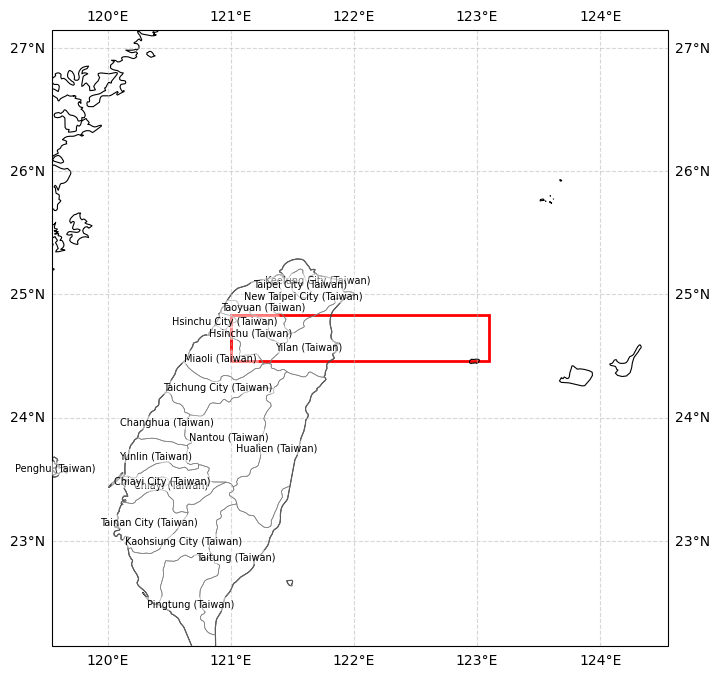

In [7]:
# dx = 500e3
# R = 6.371e6
# lat = 25 * np.pi / 180

# # Longitude difference
# dlon = dx / (R * np.cos(lat))
# dlon_deg = dlon * 180/np.pi
# print("Longitude span (deg):", dlon_deg) #~5 degrees

# # Latitude difference
# dlat = dx / R
# dlat_deg = dlat * 180/np.pi
# print("Latitude span (deg):", dlat_deg) #~5 degrees


mapPlotting = MapPlotting(
    sw_corner=(24.46, 121.00),  # (lat_min, lon_min)
    ne_corner=(24.83, 123.10),  # (lat_max, lon_max)
    delta=2.5,
    fontsize=7
)
mapPlotting.PlotBoundingBox()

In [8]:
################################################################################

In [31]:
#SET UP DIRECTORIES
Campaign="PRECIP"

#Code Directory
Code_Directory="/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/Observation_Data"
Code_Directory=os.path.join(Code_Directory,Campaign)
print("Code Directory Set as:", Code_Directory, '\n')

#Data Directory
DataType="PRECIP_Radiosonde_Dataset"
Observation_Data_Directory = "/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data"
Data_Directory = os.path.join(Observation_Data_Directory,Campaign,DataType,"unzip")
print("Data Directory Set as:", Data_Directory, '\n')
FileList = ListFiles(Data_Directory)

#Output Directory
Output_Directory="/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data"
Output_Directory=os.path.join(Output_Directory,Campaign,DataType)

Code Directory Set as: /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/Observation_Data/PRECIP 

Data Directory Set as: /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/DATA/Observation_Data/PRECIP/PRECIP_Radiosonde_Dataset/unzip 

Listing first 10 files:
 ['46757_2022070606.L2.eol', 'yonaguni_2022080303.L2.csv', '46757_2022072112.L2.csv', '46757_2022080406.L2.png', 'yonaguni_2022071206.L2.png', '46757_2022061406.L2.png', '46757_2022072500.L2.csv', 'yonaguni_2022072100.L2.csv', 'yonaguni_2022073000.L2.csv', '46757_2022060806.L2.png'] 



In [27]:
import os

def ListPNGs(directory):
    # Get only files starting with '46757' and ending with '.png'
    files = [f for f in os.listdir(directory) if f.startswith("46757") and f.endswith(".png")]
    
    # Sort by the timestamp portion (after '46757_' and before '.L2.png')
    files_sorted = sorted(files, key=lambda x: x.split('_')[1].split('.')[0])
    
    return files_sorted

# Example usage:
png_files = ListPNGs(Data_Directory)
print("Filtered and sorted PNGs:\n", png_files[:10], "\n")

Filtered and sorted PNGs:
 ['46757_2022052406.L2.png', '46757_2022052500.L2.png', '46757_2022052506.L2.png', '46757_2022052600.L2.png', '46757_2022052606.L2.png', '46757_2022052612.L2.png', '46757_2022052618.L2.png', '46757_2022052700.L2.png', '46757_2022052706.L2.png', '46757_2022052712.L2.png'] 



In [28]:
#PLOTTING FUNCTIONS
###################################

In [29]:
def get_png_files(directory, prefix="46757"):
    """Return sorted list of PNG files for a given prefix."""
    files = [f for f in os.listdir(directory) if f.startswith(prefix) and f.endswith(".png")]
    return sorted(files, key=lambda x: x.split('_')[1].split('.')[0])

def PlotPNGs(directory, files_to_plot, prefix, save_directory=None, show_plot=True):
    """Plot up to 9 PNGs from a given list, with optional save and suppress output in Jupyter."""
    if not files_to_plot:
        print("No PNG files provided.")
        return
    
    # Extract start & end dates
    start_date = files_to_plot[0].split('_')[1][:8]
    end_date   = files_to_plot[-1].split('_')[1][:8]
    label_str  = f"{prefix}_{start_date}-{end_date}"
    
    # Set up figure
    fig = plt.figure(figsize=(12, 12))
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.05, wspace=0.05)
    
    for i, fname in enumerate(files_to_plot):
        ax = fig.add_subplot(gs[i])
        img_path = os.path.join(directory, fname)
        img = plt.imread(img_path)
        ax.imshow(img)
        ax.set_title(fname, fontsize=8)
        ax.axis('off')
    
    fig.suptitle(label_str, fontsize=14, y=0.92)
    print(f"Plotting {label_str}")
    
    # Save if requested
    if save_directory is not None:
        os.makedirs(save_directory, exist_ok=True)
        save_path = os.path.join(save_directory, f"{label_str}.png")
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        print(f"Saved plot to {save_path}")
    
    # Only show if requested
    if show_plot:
        plt.show()
    else:
        plt.close(fig)

In [30]:
#PLOTTING ALL PLOTS

# Get all PNG files
all_pngs = get_png_files(Data_Directory, prefix="46757")

# Setting Plot Output Directory
# save_directory = None 
Save_FolderName = "PRECIP_Radiosonde"
save_directory=os.path.join(Output_Directory,Save_FolderName)

# Loop over chunks of 9 with progress bar
for count, i in enumerate(tqdm(range(0, len(all_pngs), 9), desc="Plotting PNG batches"), start=1):
    batch = all_pngs[i:i+9]   # grab a slice of 9
    print(f"Processing batch {count} with {len(batch)} files")
    PlotPNGs(Data_Directory, batch, prefix="PRECIP_Radiosonde", save_directory=save_directory, show_plot=False)

    # break

Plotting PNG batches:   0%|          | 0/37 [00:00<?, ?it/s]

Processing batch 1 with 9 files
Plotting PRECIP_Radiosonde_20220524-20220527


Plotting PNG batches:   3%|▎         | 1/37 [00:02<01:18,  2.17s/it]

Saved plot to /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data/PRECIP_Radiosonde/PRECIP_Radiosonde_20220524-20220527.png
Processing batch 2 with 9 files
Plotting PRECIP_Radiosonde_20220527-20220529


Plotting PNG batches:   5%|▌         | 2/37 [00:04<01:13,  2.10s/it]

...

Saved plot to /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data/PRECIP_Radiosonde/PRECIP_Radiosonde_20220806-20220808.png
Processing batch 36 with 9 files
Plotting PRECIP_Radiosonde_20220808-20220810


Plotting PNG batches:  97%|█████████▋| 36/37 [01:15<00:02,  2.13s/it]

Saved plot to /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data/PRECIP_Radiosonde/PRECIP_Radiosonde_20220808-20220810.png
Processing batch 37 with 1 files
Plotting PRECIP_Radiosonde_20220811-20220811


Plotting PNG batches: 100%|██████████| 37/37 [01:15<00:00,  2.04s/it]

Saved plot to /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data/PRECIP_Radiosonde/PRECIP_Radiosonde_20220811-20220811.png
